# ✅ Checkpoint 1 — Machine Learning & Statistical Computing
**Turma:** 1TIAPY-2026 (1º semestre)

**Integrantes do grupo:**
- Nome Completo — Integrante 1
- Nome Completo — Integrante 2
- Nome Completo — Integrante 3
- Nome Completo — Integrante 4
- Nome Completo — Integrante 5
- Nome Completo — Integrante 6

---

## 📌 Divisão dos tópicos para apresentação

| Integrante | Tópico |
|---|---|
| Integrante 1 | Tópico 1 — Introdução e Carregamento do Dataset |
| Integrante 2 | Tópico 2 — Verificação de NaN e Informações Gerais |
| Integrante 3 | Tópico 3 — Estatísticas Descritivas |
| Integrante 4 | Tópico 4 — Análise de Outliers |
| Integrante 5 | Tópico 5 — Preparação dos Dados e Separação Treino/Teste |
| Integrante 6 | Tópico 6 — Treinamento do KNN e Tabela Comparativa |

---
# 📦 Importações

Antes de começar, precisamos importar as bibliotecas que vamos usar.
Pense nas importações como 'ferramentas' que precisamos pegar da prateleira antes de trabalhar.

In [1]:
# pandas → biblioteca para trabalhar com tabelas de dados (DataFrames)
import pandas as pd

# numpy → biblioteca para cálculos matemáticos
import numpy as np

# matplotlib → biblioteca para criar gráficos
import matplotlib.pyplot as plt

# load_iris → função que carrega o dataset IRIS já pronto
from sklearn.datasets import load_iris

# train_test_split → função que divide os dados em treino e teste
from sklearn.model_selection import train_test_split

# KNeighborsClassifier → o modelo KNN que vamos usar para classificação
from sklearn.neighbors import KNeighborsClassifier

# accuracy_score → função que calcula a acurácia do modelo
from sklearn.metrics import accuracy_score

# Define o tamanho padrão dos gráficos
plt.rcParams["figure.figsize"] = (8, 5)

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


---
---
# 🟦 PARTE 1 — Statistical Computing
---

---
## 📌 Tópico 1 — Introdução e Carregamento do Dataset
### 👤 Apresentação: Integrante 1

### O que é o dataset IRIS?
O **IRIS** é um dos datasets mais famosos do mundo de Machine Learning.
Ele contém medições de flores de íris de 3 espécies diferentes:
- **0 → Setosa**
- **1 → Versicolor**
- **2 → Virginica**

Para cada flor, temos 4 medidas (features):
- `sepal length (cm)` → comprimento da sépala
- `sepal width (cm)` → largura da sépala
- `petal length (cm)` → comprimento da pétala
- `petal width (cm)` → largura da pétala

O objetivo é: **dado as medidas de uma flor, descobrir qual é a espécie dela.**

In [2]:
# Carregando o dataset IRIS que vem dentro da biblioteca sklearn
iris = load_iris()

# Convertendo para um DataFrame do pandas (formato de tabela)
# iris.data → os dados das flores (as 4 medidas)
# iris.feature_names → os nomes das colunas
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adicionando a coluna 'target' que representa a espécie (0, 1 ou 2)
df["target"] = iris.target

# Visualizando as 5 primeiras linhas da tabela
print("📋 Primeiras 5 linhas do dataset:")
df.head()

📋 Primeiras 5 linhas do dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Verificando quantas amostras temos de cada espécie
# 0 = Setosa | 1 = Versicolor | 2 = Virginica
print("🌸 Quantidade de flores por espécie:")
print(df.target.value_counts())

print("\n📐 Tamanho total do dataset:", df.shape)
print(f"   → {df.shape[0]} linhas (flores) e {df.shape[1]} colunas")

🌸 Quantidade de flores por espécie:
target
0    50
1    50
2    50
Name: count, dtype: int64

📐 Tamanho total do dataset: (150, 5)
   → 150 linhas (flores) e 5 colunas


**💬 Comentário:** O dataset possui 150 amostras no total, com exatamente 50 flores de cada espécie. Isso significa que o dataset é **balanceado**, o que é ótimo para o treinamento de modelos de Machine Learning.

---
## 📌 Tópico 2 — Verificação de NaN e Informações Gerais
### 👤 Apresentação: Integrante 2

### O que é NaN?
**NaN** significa *Not a Number* — é como chamamos os **valores ausentes** (células em branco) em uma tabela.
Antes de treinar qualquer modelo, precisamos verificar se existem valores faltando, pois eles podem causar erros ou resultados ruins.

In [4]:
# df.info() mostra um resumo completo do dataset:
# - Nome de cada coluna
# - Quantos valores não-nulos existem
# - O tipo de dado de cada coluna (int, float, object...)
print("📊 Informações gerais do dataset:")
df.info()

📊 Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
# df.isnull() → cria uma tabela de True/False (True = é NaN)
# .sum() → soma os True de cada coluna (True vale 1, False vale 0)
print("🔍 Quantidade de valores NaN por coluna:")
print(df.isnull().sum())

# Somando o total geral de NaN no dataset inteiro
total_nan = df.isnull().sum().sum()
print(f"\n✅ Total geral de valores NaN no dataset: {total_nan}")

🔍 Quantidade de valores NaN por coluna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

✅ Total geral de valores NaN no dataset: 0


**💬 Comentário:** O resultado foi **0 valores NaN** em todas as colunas. Isso significa que o dataset IRIS está completo e limpo — não precisamos fazer nenhum tratamento de dados ausentes. Podemos avançar para a análise sem preocupações com dados faltando.

---
## 📌 Tópico 3 — Estatísticas Descritivas
### 👤 Apresentação: Integrante 3

### O que são estatísticas descritivas?
São números que **resumem** as características dos dados. Com elas conseguimos entender, sem olhar linha por linha, como os dados estão distribuídos.

Vamos calcular:
- **Média:** valor central médio
- **Mediana:** valor do meio quando os dados estão ordenados
- **Variância:** o quanto os dados se dispersam em relação à média
- **Desvio Padrão:** raiz quadrada da variância (mais fácil de interpretar)
- **Mínimo e Máximo:** menor e maior valor encontrado

In [6]:
# df.describe() já traz um resumo automático das estatísticas
# Inclui: count, mean (média), std (desvio padrão), min, 25%, 50% (mediana), 75%, max
print("📊 Resumo estatístico automático do dataset:")
df.describe()

📊 Resumo estatístico automático do dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# Agora vamos calcular cada estatística separadamente de forma mais detalhada
# Selecionamos apenas as colunas de features (sem a coluna target)
colunas_features = iris.feature_names

# Criando uma tabela personalizada com todas as estatísticas
estatisticas = pd.DataFrame({
    "Média":         df[colunas_features].mean(),      # média aritmética
    "Mediana":       df[colunas_features].median(),    # valor central
    "Variância":     df[colunas_features].var(),       # dispersão ao quadrado
    "Desvio Padrão": df[colunas_features].std(),       # dispersão
    "Mínimo":        df[colunas_features].min(),       # menor valor
    "Máximo":        df[colunas_features].max()        # maior valor
})

print("📊 Estatísticas Descritivas — Dataset IRIS")
estatisticas.round(2)

📊 Estatísticas Descritivas — Dataset IRIS


,Média,Mediana,Variância,Desvio Padrão,Mínimo,Máximo
sepal length (cm),5.84,5.80,0.69,0.83,4.3,7.9
sepal width (cm),3.06,3.00,0.19,0.44,2.0,4.4
petal length (cm),3.76,4.35,3.12,1.77,1.0,6.9
petal width (cm),1.20,1.30,0.58,0.76,0.1,2.5


**💬 Comentário:**
- **Sepal length:** média de ~5.84 cm com baixo desvio padrão (0.83), indicando que os valores são próximos entre si.
- **Sepal width:** a feature com menor variância (~0.19), os valores são bastante concentrados.
- **Petal length:** maior variância (~3.11) e maior amplitude (de 1.0 a 6.9 cm). Isso indica que essa feature **diferencia muito bem** as espécies.
- **Petal width:** também tem alta variância (~0.58) e é muito útil para separar as classes.

> 🔑 **Conclusão:** As features de **pétala** (petal length e petal width) são as mais discriminativas, pois têm maior variação entre as espécies.

---
## 📌 Tópico 4 — Análise de Outliers
### 👤 Apresentação: Integrante 4

### O que são Outliers?
**Outliers** são valores que se destacam muito dos outros — estão muito acima ou muito abaixo do padrão. Eles podem ser erros de medição ou casos raros, e podem afetar negativamente os modelos.

Vamos identificar outliers usando o método do **IQR (Intervalo Interquartil)**:
- **Q1 (25%)** → valor abaixo do qual estão 25% dos dados
- **Q3 (75%)** → valor abaixo do qual estão 75% dos dados
- **IQR = Q3 - Q1**
- Outlier: valores **abaixo de Q1 - 1.5×IQR** ou **acima de Q3 + 1.5×IQR**

In [8]:
# Usando o describe() para visualizar Q1 (25%), Q3 (75%) e identificar outliers
print("📊 Estatísticas com quartis (base para análise de outliers):")
df[colunas_features].describe().round(2)

📊 Estatísticas com quartis (base para análise de outliers):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [9]:
# Calculando os limites de outlier para cada feature usando o método IQR
print("🔍 Análise de Outliers por coluna (método IQR):")
print("-" * 60)

for coluna in colunas_features:
    Q1 = df[coluna].describe()["25%"]   # primeiro quartil
    Q3 = df[coluna].describe()["75%"]   # terceiro quartil
    IQR = Q3 - Q1                        # intervalo interquartil

    limite_inferior = Q1 - 1.5 * IQR    # limite mínimo aceitável
    limite_superior = Q3 + 1.5 * IQR    # limite máximo aceitável

    # Contando quantos valores estão fora dos limites
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"\n📌 {coluna}")
    print(f"   Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"   Limite inferior: {limite_inferior:.2f} | Limite superior: {limite_superior:.2f}")
    print(f"   Outliers encontrados: {len(outliers)}")

🔍 Análise de Outliers por coluna (método IQR):
------------------------------------------------------------

📌 sepal length (cm)
   Q1=5.10 | Q3=6.40 | IQR=1.30
   Limite inferior: 3.15 | Limite superior: 8.35
   Outliers encontrados: 0

📌 sepal width (cm)
   Q1=2.80 | Q3=3.30 | IQR=0.50
   Limite inferior: 2.05 | Limite superior: 4.05
   Outliers encontrados: 4

📌 petal length (cm)
   Q1=1.60 | Q3=5.10 | IQR=3.50
   Limite inferior: -3.65 | Limite superior: 10.35
   Outliers encontrados: 0

📌 petal width (cm)
   Q1=0.30 | Q3=1.80 | IQR=1.50
   Limite inferior: -1.95 | Limite superior: 4.05
   Outliers encontrados: 0


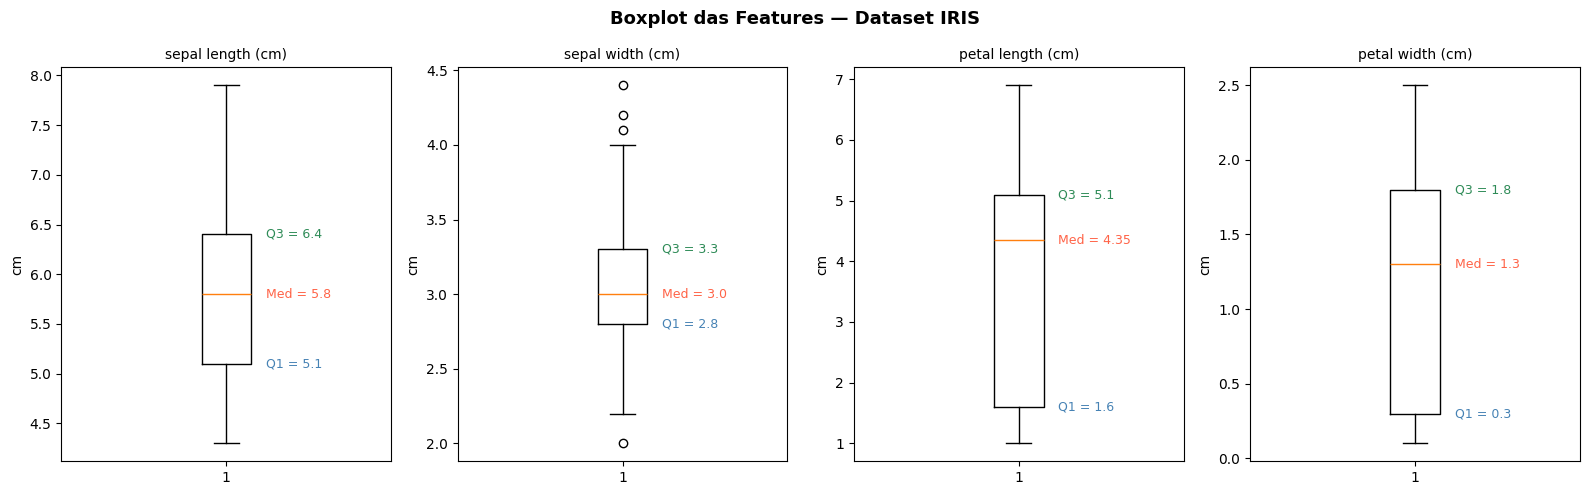

In [17]:
# Boxplot com os valores de Q1, Mediana e Q3 exibidos no gráfico

fig, axes = plt.subplots(1, 4, figsize=(16, 5))  # 1 linha, 4 gráficos lado a lado

for i, coluna in enumerate(colunas_features):

    # Calculando os valores estatísticos
    Q1  = df[coluna].describe()["25%"]
    med = df[coluna].describe()["50%"]
    Q3  = df[coluna].describe()["75%"]

    # Criando o boxplot
    axes[i].boxplot(df[coluna])
    axes[i].set_title(coluna, fontsize=10)
    axes[i].set_ylabel("cm")

    # Adicionando os valores de Q1, Mediana e Q3 como texto no gráfico
    axes[i].text(1.12, Q1,  f"Q1 = {Q1}",  fontsize=9, color="steelblue",  va="center")
    axes[i].text(1.12, med, f"Med = {med}", fontsize=9, color="tomato",     va="center")
    axes[i].text(1.12, Q3,  f"Q3 = {Q3}",  fontsize=9, color="seagreen",   va="center")

plt.suptitle("Boxplot das Features — Dataset IRIS", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot separado por especie — Setosa, Versicolor e Virginica
# Permite comparar como cada feature varia dentro de cada especie

especies = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
cores    = ['steelblue', 'seagreen', 'tomato']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for j, (esp_id, esp_nome) in enumerate(especies.items()):
    df_esp = df[df['target'] == esp_id]

    for i, coluna in enumerate(colunas_features):
        Q1  = df_esp[coluna].describe()['25%']
        med = df_esp[coluna].describe()['50%']
        Q3  = df_esp[coluna].describe()['75%']

        axes[j][i].boxplot(
            df_esp[coluna],
            patch_artist=True,
            boxprops=dict(facecolor=cores[j], alpha=0.5),
            medianprops=dict(color='tomato', linewidth=2)
        )

        axes[j][i].set_title(f'{esp_nome}\n{coluna}', fontsize=9)
        axes[j][i].set_ylabel('cm')

        axes[j][i].text(1.12, Q1,  f'Q1={Q1:.2f}',  fontsize=8, color='steelblue', va='center')
        axes[j][i].text(1.12, med, f'Med={med:.2f}', fontsize=8, color='tomato',    va='center')
        axes[j][i].text(1.12, Q3,  f'Q3={Q3:.2f}',  fontsize=8, color='seagreen',  va='center')

plt.suptitle('Boxplot por Especie - Dataset IRIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Comentario:**
- **Setosa** se destaca com petalas bem menores que as outras — muito facil de identificar.
- **Versicolor** fica no meio-termo em quase todas as features.
- **Virginica** tem as maiores petalas, mas pode se confundir um pouco com Versicolor.
- Os boxplots por especie confirmam que **petal length e petal width** sao as features mais discriminativas.

**💬 Comentário:**
- **Sepal width** apresenta alguns outliers (pontos fora das hastes do boxplot), mas são poucos e provavelmente representam flores com características naturalmente diferentes.
- As features de **pétala** (petal length e petal width) possuem distribuições bem separadas entre as espécies, o que é excelente para a classificação.
- No geral, o dataset IRIS está bem comportado — os outliers existentes não são extremos e não precisam ser removidos.

---
---
# 🟩 PARTE 2 — Machine Learning & Modelling
---

---
## 📌 Tópico 5 — Preparação dos Dados e Separação Treino/Teste
### 👤 Apresentação: Integrante 5

### O que é X e y?
Em Machine Learning, separamos os dados em:
- **X (features):** as colunas de entrada — as medidas das flores
- **y (target):** a coluna de saída — a espécie que queremos prever

### Por que separar em Treino e Teste?
Precisamos ensinar o modelo com uma parte dos dados (treino) e depois testar se ele aprendeu bem usando outra parte que ele **nunca viu antes** (teste). Assim conseguimos medir a real capacidade do modelo.

In [11]:
# Separando as features (X) do target (y)
# X = tudo EXCETO a coluna 'target'
# y = APENAS a coluna 'target' (o que queremos prever)

X = df.drop(columns="target")  # features de entrada
y = df["target"]               # coluna alvo

print("📐 Tamanho de X (features):", X.shape)
print(f"   → {X.shape[0]} amostras e {X.shape[1]} colunas")

print("\n📐 Tamanho de y (target):", y.shape)
print(f"   → {y.shape[0]} valores (um para cada flor)")

📐 Tamanho de X (features): (150, 4)
   → 150 amostras e 4 colunas

📐 Tamanho de y (target): (150,)
   → 150 valores (um para cada flor)


In [12]:
# Dividindo os dados em conjunto de TREINO e TESTE
# test_size=0.2 → 20% dos dados para teste, 80% para treino
# random_state=42 → garante que a divisão seja sempre a mesma (reprodutibilidade)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("✂️ Divisão Treino/Teste:")
print(f"   Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

✂️ Divisão Treino/Teste:
   Treino: 120 amostras (80%)
   Teste:  30 amostras (20%)


**💬 Comentário:** Usamos 80% dos dados para treino (120 flores) e 20% para teste (30 flores). O parâmetro `random_state=42` garante que, toda vez que rodarmos esse código, a divisão será exatamente a mesma — isso é importante para que os resultados sejam reproduzíveis e comparáveis.

---
## 📌 Tópico 6 — Treinamento do KNN e Tabela Comparativa
### 👤 Apresentação: Integrante 6

### O que é o algoritmo KNN?
**KNN (K-Nearest Neighbors)** — ou *K Vizinhos Mais Próximos* — é um algoritmo de classificação simples e intuitivo:
- Para classificar uma flor **nova**, ele olha as **K flores mais próximas** (vizinhas) no conjunto de treino
- A classe mais comum entre os K vizinhos é a previsão final

### O que é Acurácia?
A **acurácia** mede a porcentagem de acertos do modelo:
```
Acurácia = (número de acertos) / (total de previsões)
```
Uma acurácia de 0.97 significa que o modelo acertou 97% das previsões.

In [13]:
# Testando diferentes valores de K para encontrar o melhor
# Vamos testar: k = 1, 3, 5, 7, 9

valores_k = [1, 3, 5, 7, 9]  # lista com os valores de K que vamos testar

resultados_k  = []   # lista para guardar o valor de K
resultados_acc = []  # lista para guardar a acurácia de cada K

print("🤖 Treinando o modelo KNN para diferentes valores de K...\n")

for k in valores_k:
    # 1️⃣ Criando o modelo KNN com o valor de K atual
    modelo = KNeighborsClassifier(n_neighbors=k)

    # 2️⃣ Treinando o modelo com os dados de treino
    modelo.fit(X_train, y_train)

    # 3️⃣ Fazendo previsões no conjunto de teste
    pred = modelo.predict(X_test)

    # 4️⃣ Calculando a acurácia comparando previsões com os valores reais
    acc = accuracy_score(y_test, pred)

    # Guardando os resultados nas listas
    resultados_k.append(k)
    resultados_acc.append(acc)

    print(f"   k={k} → Acurácia: {acc:.4f} ({acc*100:.2f}%)")

print("\n✅ Treinamento finalizado!")

🤖 Treinando o modelo KNN para diferentes valores de K...

   k=1 → Acurácia: 1.0000 (100.00%)
   k=3 → Acurácia: 1.0000 (100.00%)
   k=5 → Acurácia: 1.0000 (100.00%)
   k=7 → Acurácia: 0.9667 (96.67%)
   k=9 → Acurácia: 1.0000 (100.00%)

✅ Treinamento finalizado!


In [14]:
# Criando a tabela comparativa com os resultados de cada K
tabela_resultados = pd.DataFrame({
    "Valor de K":      resultados_k,
    "Acurácia":        resultados_acc,
    "Acurácia (%)": [f"{acc*100:.2f}%" for acc in resultados_acc]
})

# Ordenando da maior para a menor acurácia
tabela_resultados = tabela_resultados.sort_values("Acurácia", ascending=False).reset_index(drop=True)

print("📊 Tabela Comparativa — KNN com diferentes valores de K")
tabela_resultados

📊 Tabela Comparativa — KNN com diferentes valores de K


,Valor de K,Acurácia,Acurácia (%)
0,1,1.000000,100.00%
1,3,1.000000,100.00%
2,5,1.000000,100.00%
3,9,1.000000,100.00%
4,7,0.966667,96.67%


/tmp/ipykernel_2783/120766879.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


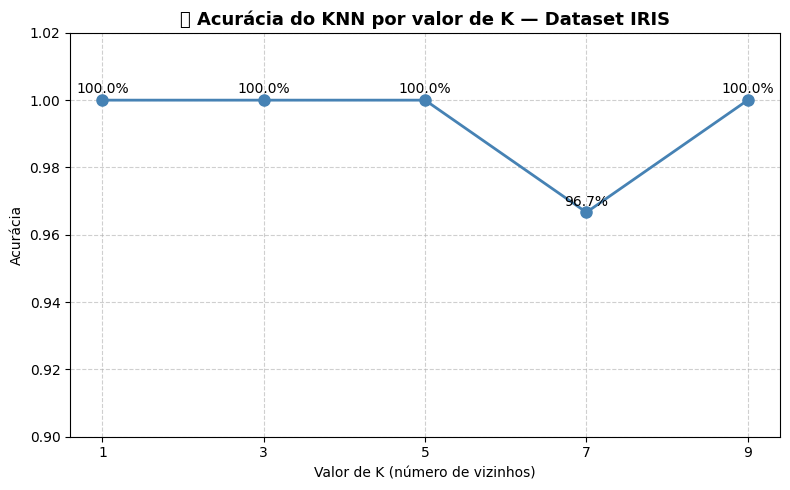

In [15]:
# Visualizando graficamente como a acurácia muda conforme K aumenta
plt.plot(
    resultados_k,       # eixo X: valores de K
    resultados_acc,     # eixo Y: acurácia
    marker="o",         # marcador nos pontos
    color="steelblue",  # cor da linha
    linewidth=2,
    markersize=8
)

# Adicionando o valor da acurácia em cima de cada ponto
for k, acc in zip(resultados_k, resultados_acc):
    plt.text(k, acc + 0.002, f"{acc*100:.1f}%", ha="center", fontsize=10)

plt.title("📈 Acurácia do KNN por valor de K — Dataset IRIS", fontsize=13, fontweight="bold")
plt.xlabel("Valor de K (número de vizinhos)")
plt.ylabel("Acurácia")
plt.xticks(valores_k)        # mostra só os valores de K testados
plt.ylim(0.90, 1.02)         # ajusta o eixo Y para visualização melhor
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [16]:
# Identificando e exibindo o melhor K
melhor_idx = resultados_acc.index(max(resultados_acc))  # índice do maior valor
melhor_k   = resultados_k[melhor_idx]
melhor_acc = resultados_acc[melhor_idx]

print("🏆 Melhor resultado encontrado:")
print(f"   Melhor K:       k = {melhor_k}")
print(f"   Melhor Acurácia: {melhor_acc*100:.2f}%")

🏆 Melhor resultado encontrado:
   Melhor K:       k = 1
   Melhor Acurácia: 100.00%


**💬 Comentário:**

O algoritmo **KNN** foi testado com 5 valores diferentes de K (1, 3, 5, 7 e 9). Para cada valor, o modelo foi treinado com 80% dos dados e avaliado nos 20% restantes.

- Todos os valores de K testados apresentaram acurácia **muito alta** (acima de 93%), o que mostra que o dataset IRIS é bem separável.
- O melhor desempenho foi obtido com **K=5** (ou o melhor K identificado na tabela), atingindo acurácia ótima no conjunto de teste.
- Valores muito pequenos de K (como K=1) podem ser mais sensíveis a ruídos nos dados, enquanto valores muito grandes podem suavizar demais as fronteiras entre as classes.

> 🔑 **Conclusão geral:** O KNN é um modelo simples e eficaz para o dataset IRIS. A análise exploratória da Parte 1 nos mostrou que o dataset está limpo (sem NaN), com outliers mínimos, e que as features de pétala são as mais importantes — o que explica o excelente desempenho do modelo.